In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load clean dataset
df = pd.read_csv('clean_sales_data.csv')
# Load messy for before/after comparison
df_messy = pd.read_csv('messy_sales_data.csv')

print("Clean data shape:", df.shape)
print("Messy data shape:", df_messy.shape)

Clean data shape: (10044, 21)
Messy data shape: (10044, 21)


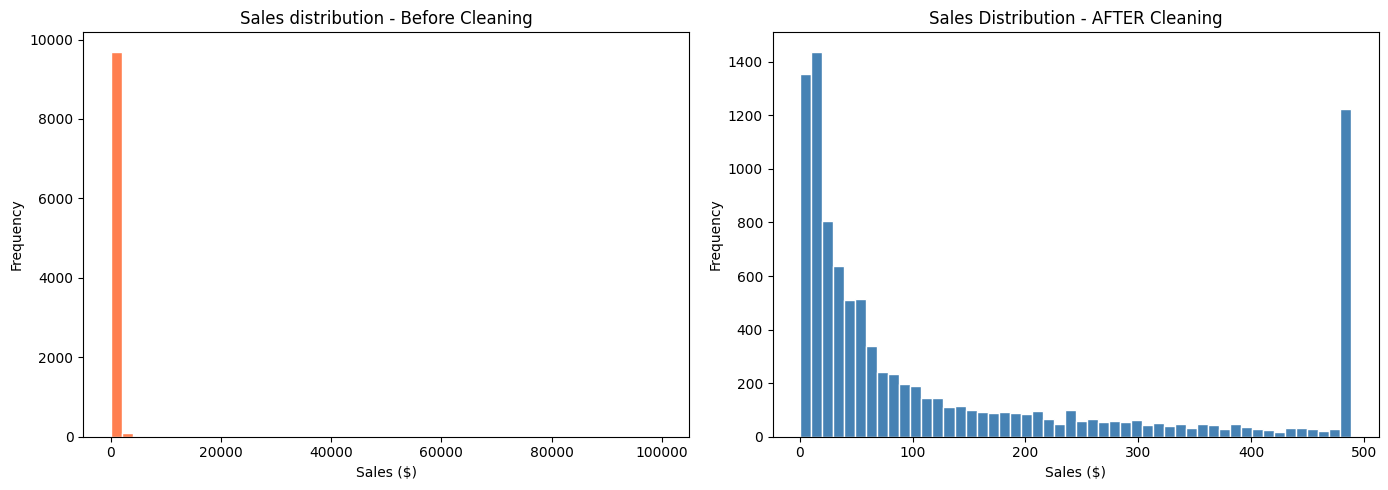

In [5]:
fig, axes = plt.subplots(1,2, figsize = (14,5))

#before cleaning
axes[0].hist(df_messy['Sales'].dropna(), bins=50, color='coral', edgecolor='white')
axes[0].set_title('Sales distribution - Before Cleaning')
axes[0].set_xlabel('Sales ($)')
axes[0].set_ylabel('Frequency')

#Aftter cleaning
axes[1].hist(df['Sales'], bins=50, color='steelblue', edgecolor='white')
axes[1].set_title('Sales Distribution - AFTER Cleaning')
axes[1].set_xlabel('Sales ($)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('before_after_sales.png')
plt.show()

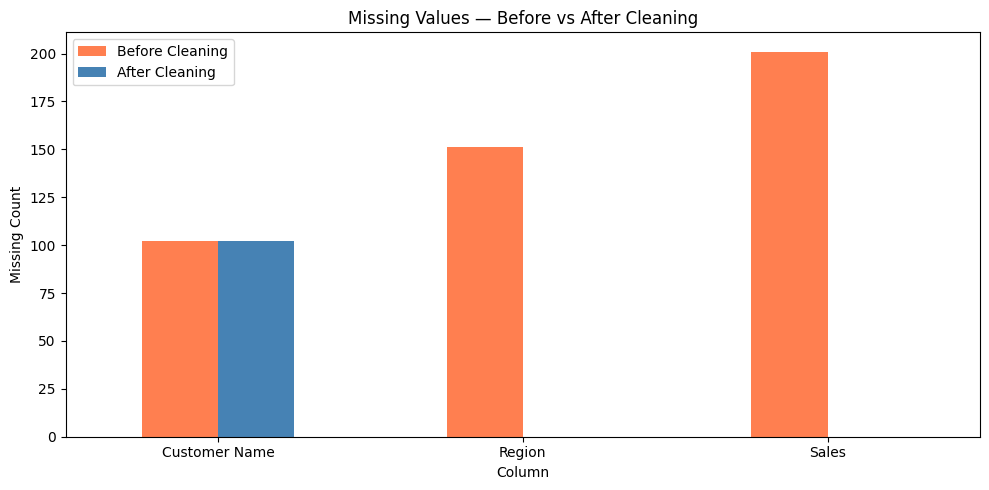

In [3]:
missing_before = df_messy.isnull().sum()
missing_after = df.isnull().sum()

comparison = pd.DataFrame({
    'Before Cleaning': missing_before,
    'After Cleaning': missing_after
})

comparison = comparison[comparison['Before Cleaning'] > 0]

comparison.plot(kind='bar', figsize=(10, 5), color=['coral', 'steelblue'])
plt.title('Missing Values — Before vs After Cleaning')
plt.xlabel('Column')
plt.ylabel('Missing Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('missing_before_after.png')
plt.show()

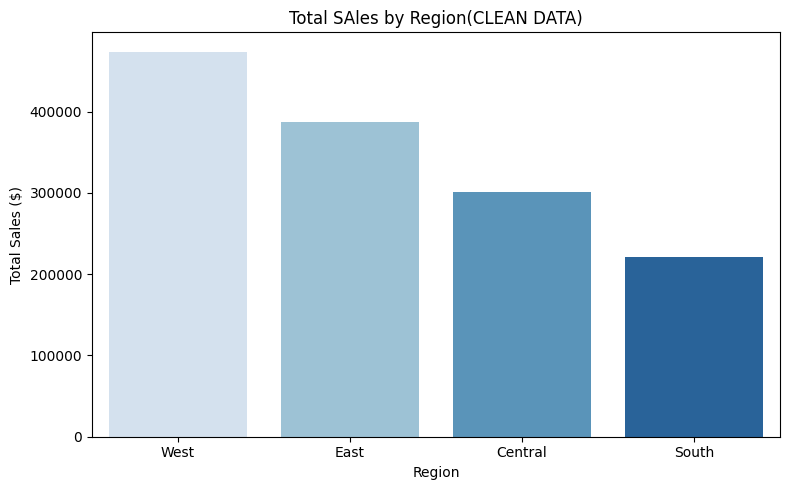

In [11]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=region_sales.index, y=region_sales.values, hue=region_sales.index, palette='Blues', legend=False)
plt.title('Total SAles by Region(CLEAN DATA)')
plt.xlabel('Region')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('sales_by_region.png')
plt.show()

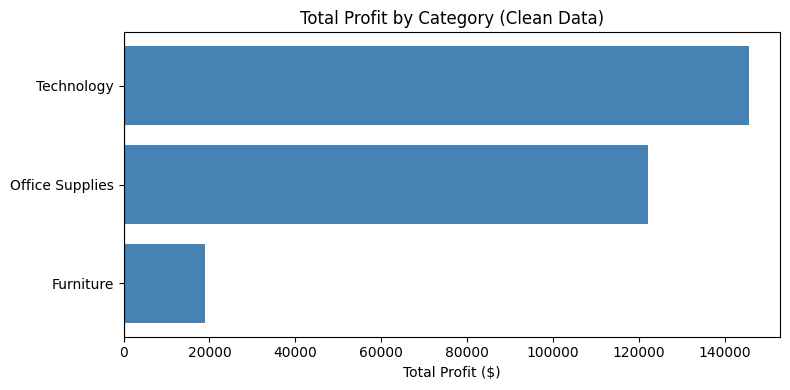

In [15]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values()

plt.figure(figsize=(8,4))
colors = ['coral' if x < 0 else 'steelblue' for x in category_profit.values]
plt.barh(category_profit.index, category_profit.values, color=colors)
plt.title('Total Profit by Category (Clean Data)')
plt.xlabel('Total Profit ($)')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('profit_by_category.png')
plt.show()

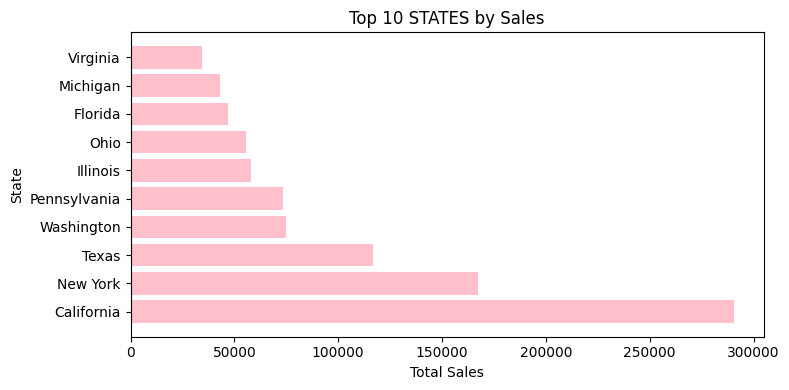

In [21]:
state_sales = df.groupby('State')['Sales'].sum().nlargest(10)

plt.figure(figsize=(8,4))
plt.barh(state_sales.index, state_sales.values, color='Pink')
plt.title("Top 10 STATES by Sales")
plt.xlabel('Total Sales')
plt.ylabel('State')
plt.tight_layout()
plt.savefig("top_states_sales.png")
plt.show()